# HALO Internal Behavior Analysis

This notebook trains a small CNN on FashionMNIST using both HALO and AdamW,
then compares loss/F1 curves, analyzes the learned response policy, and
visualizes the optimizer's internal dynamics.

In [1]:
import os, sys, subprocess

BRANCH = "main"  # set to the desired branch or tag

if os.path.exists("/content"):
    subprocess.run(
        ["git", "clone", "--branch", BRANCH,
         "https://github.com/SattamAltwaim/HALO.git", "/content/HALO"],
        capture_output=True, check=False,
    )
    if "/content/HALO" not in sys.path:
        sys.path.insert(0, "/content/HALO")
else:
    parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if os.path.exists(os.path.join(parent, "halo")) and parent not in sys.path:
        sys.path.insert(0, parent)

from halo import HALO
print("HALO imported successfully")

HALO imported successfully


In [2]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA

from halo import HALO

## Configuration

In [3]:
# Hyperparameters -- shared between HALO and AdamW
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 0.01
BETA1 = 0.9
BETA2 = 0.999
EPS = 1e-8

# HALO-specific
GAMMA = 0.99
ETA_PHI = 0.01
DEGREE = 1

# Device
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Model Definition

In [4]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Data Loading

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="../data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="../data", train=False, download=True, transform=transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


## Training Loop

In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    step_losses = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        step_losses.append(loss.item())
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, f1, step_losses


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, f1


def train_model(model_cls, optimizer_name, epochs=EPOCHS):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    g = torch.Generator()
    g.manual_seed(SEED)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, generator=g,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2,
    )

    model = model_cls().to(DEVICE)

    if optimizer_name == "halo":
        optimizer = HALO(
            model.parameters(),
            lr=LR, betas=(BETA1, BETA2), eps=EPS,
            weight_decay=WEIGHT_DECAY, gamma=GAMMA,
            eta_phi=ETA_PHI, degree=DEGREE, diagnostics=True,
        )
    else:
        optimizer = optim.AdamW(
            model.parameters(),
            lr=LR, betas=(BETA1, BETA2), eps=EPS,
            weight_decay=WEIGHT_DECAY,
        )

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [], "val_loss": [],
        "train_f1": [], "val_f1": [],
    }

    all_step_losses = []

    for epoch in tqdm(range(epochs), desc=f"{optimizer_name.upper()} Training"):
        train_loss, train_f1, step_losses = train_one_epoch(model, train_loader, optimizer, criterion)
        all_step_losses.extend(step_losses)
        val_loss, val_f1 = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(f"  Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"train_f1={train_f1:.4f} val_f1={val_f1:.4f}")

    diagnostics = None
    if optimizer_name == "halo":
        diagnostics = optimizer.diagnostics.get_history()
        diagnostics["loss"] = all_step_losses

    return history, diagnostics, model

## Train with HALO

In [7]:
halo_history, halo_diagnostics, halo_model = train_model(SmallCNN, "halo")

HALO Training:  10%|█         | 1/10 [00:06<00:59,  6.66s/it]

  Epoch 1: train_loss=0.7900 val_loss=0.6174 train_f1=0.7081 val_f1=0.7696


HALO Training:  20%|██        | 2/10 [00:12<00:51,  6.45s/it]

  Epoch 2: train_loss=0.5206 val_loss=0.4900 train_f1=0.8098 val_f1=0.8126


HALO Training:  30%|███       | 3/10 [00:19<00:43,  6.28s/it]

...

  Epoch 8: train_loss=0.3015 val_loss=0.3276 train_f1=0.8915 val_f1=0.8826


HALO Training:  90%|█████████ | 9/10 [00:57<00:06,  6.47s/it]

  Epoch 9: train_loss=0.2889 val_loss=0.3253 train_f1=0.8957 val_f1=0.8830


HALO Training: 100%|██████████| 10/10 [01:03<00:00,  6.38s/it]

  Epoch 10: train_loss=0.2780 val_loss=0.3068 train_f1=0.8997 val_f1=0.8926


## Train with AdamW

In [8]:
adamw_history, adamw_diagnostics, adamw_model = train_model(SmallCNN, "adamw")

ADAMW Training:  10%|█         | 1/10 [00:04<00:44,  4.98s/it]

  Epoch 1: train_loss=0.8809 val_loss=0.6428 train_f1=0.6754 val_f1=0.7605


ADAMW Training:  20%|██        | 2/10 [00:09<00:38,  4.86s/it]

  Epoch 2: train_loss=0.5749 val_loss=0.5275 train_f1=0.7893 val_f1=0.8120


ADAMW Training:  30%|███       | 3/10 [00:14<00:33,  4.85s/it]

...

  Epoch 8: train_loss=0.3348 val_loss=0.3538 train_f1=0.8786 val_f1=0.8727


ADAMW Training:  90%|█████████ | 9/10 [00:43<00:04,  4.89s/it]

  Epoch 9: train_loss=0.3178 val_loss=0.3299 train_f1=0.8847 val_f1=0.8822


ADAMW Training: 100%|██████████| 10/10 [00:48<00:00,  4.89s/it]

  Epoch 10: train_loss=0.3074 val_loss=0.3513 train_f1=0.8879 val_f1=0.8708


## Loss Curves: HALO vs AdamW

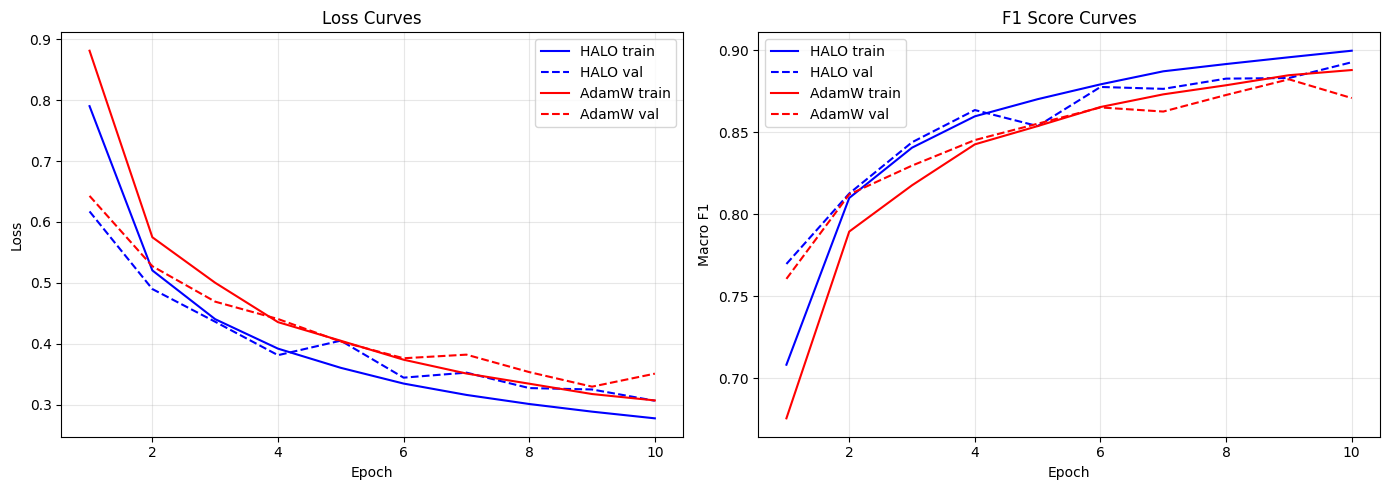

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, halo_history["train_loss"], "b-", label="HALO train")
axes[0].plot(epochs_range, halo_history["val_loss"], "b--", label="HALO val")
axes[0].plot(epochs_range, adamw_history["train_loss"], "r-", label="AdamW train")
axes[0].plot(epochs_range, adamw_history["val_loss"], "r--", label="AdamW val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, halo_history["train_f1"], "b-", label="HALO train")
axes[1].plot(epochs_range, halo_history["val_f1"], "b--", label="HALO val")
axes[1].plot(epochs_range, adamw_history["train_f1"], "r-", label="AdamW train")
axes[1].plot(epochs_range, adamw_history["val_f1"], "r--", label="AdamW val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("F1 Score Curves")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phi Parameter Evolution

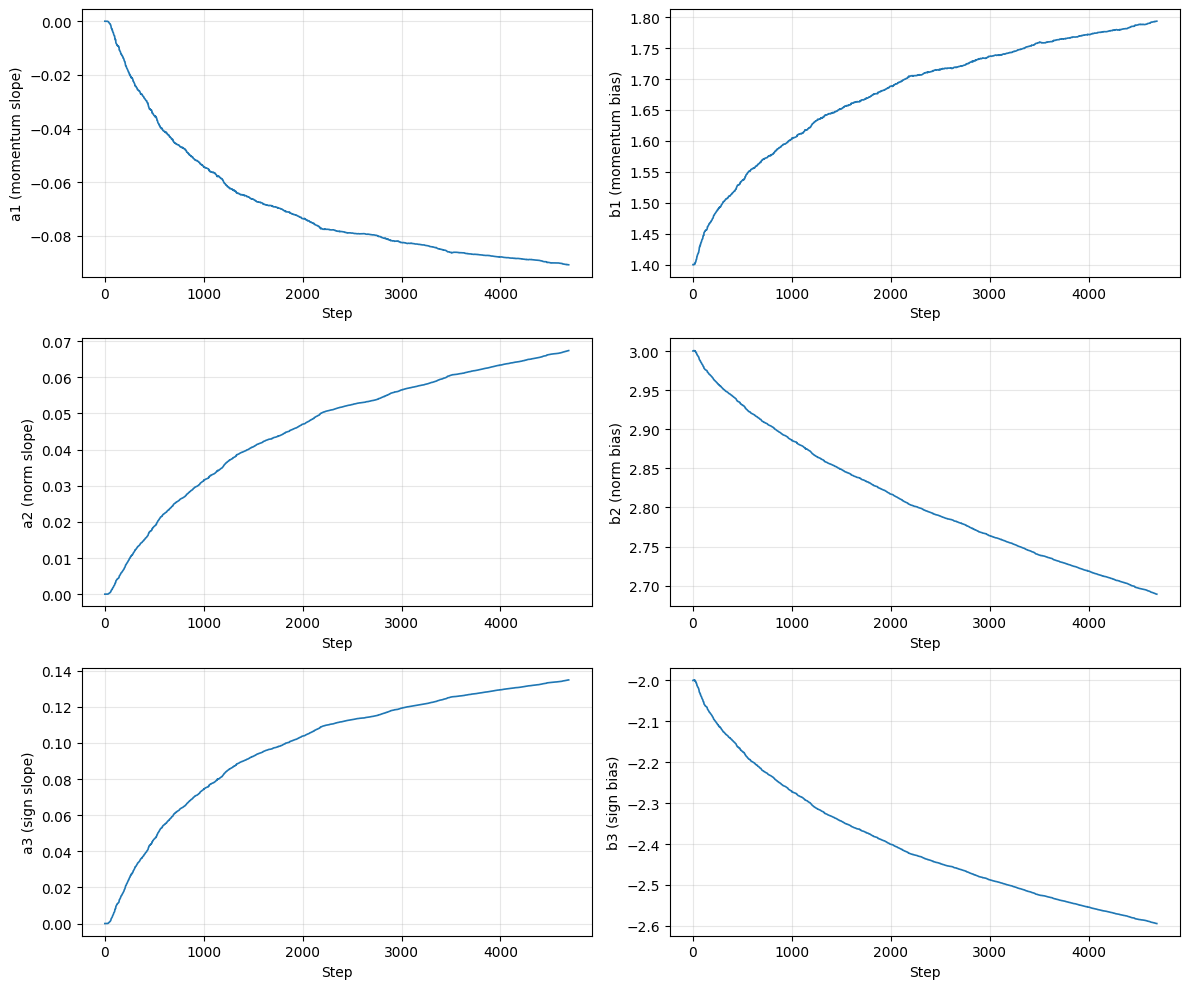

In [10]:
n_phi = 3 * (DEGREE + 1)
policy_names = ["momentum", "normalization", "sign"]
n_per_policy = DEGREE + 1

ncols = min(n_phi, 3)
nrows = (n_phi + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i in range(n_phi):
    policy_idx = i // n_per_policy
    coeff_idx = i % n_per_policy
    power = DEGREE - coeff_idx
    key = f"phi_{i}"
    label = f"{policy_names[policy_idx]} coeff (rho^{power})" if power > 0 else f"{policy_names[policy_idx]} bias"
    axes_flat[i].plot(halo_diagnostics["step"], halo_diagnostics[key], "-", linewidth=1.2)
    axes_flat[i].set_xlabel("Step")
    axes_flat[i].set_ylabel(label)
    axes_flat[i].grid(True, alpha=0.3)

for j in range(n_phi, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## Policy Values Trajectory

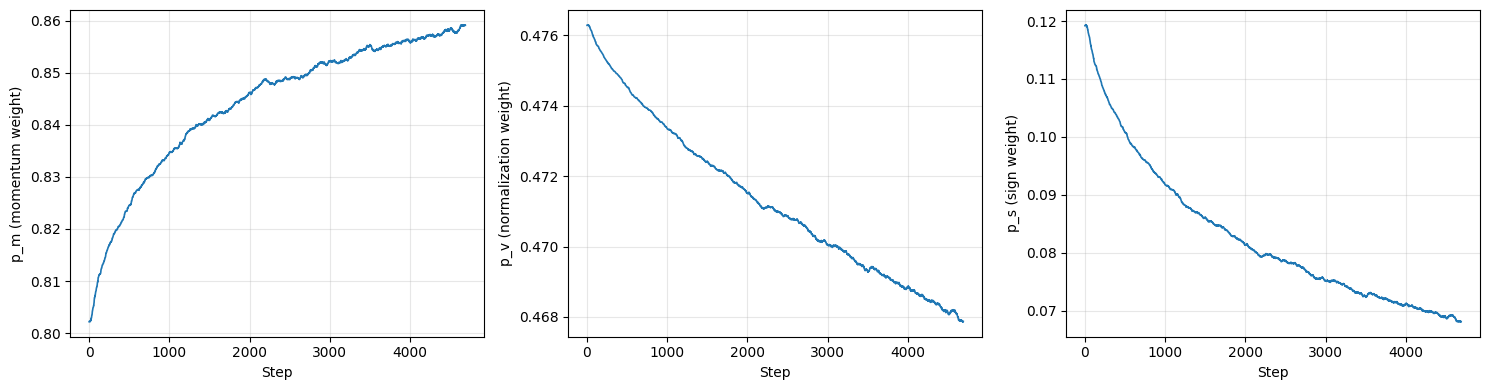

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
policy_keys = ["p_m", "p_v", "p_s"]
policy_labels = [
    "p_m (momentum weight)",
    "p_v (normalization weight)",
    "p_s (sign weight)",
]

for ax, key, label in zip(axes, policy_keys, policy_labels):
    ax.plot(halo_diagnostics["step"], halo_diagnostics[key], "-", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Response Policy Heatmap
Shows what the optimizer learned: p_m, p_v, p_s as a function of rho.

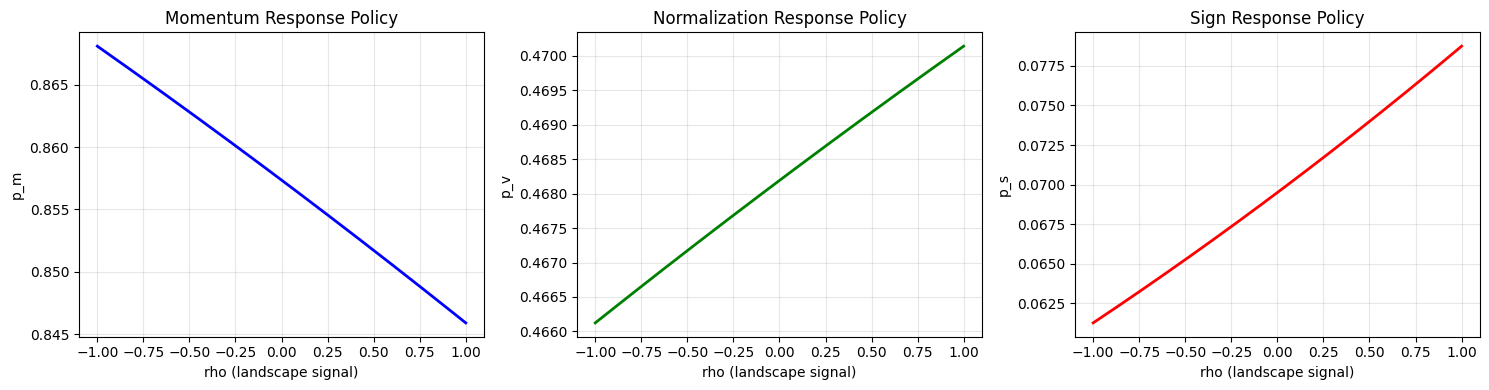

In [12]:
from halo.optimizer import _horner

n_per_policy = DEGREE + 1
phi_final = torch.tensor([halo_diagnostics[f"phi_{i}"][-1]
                          for i in range(3 * n_per_policy)])

coeffs_m = phi_final[:n_per_policy]
coeffs_v = phi_final[n_per_policy : 2 * n_per_policy]
coeffs_s = phi_final[2 * n_per_policy:]

rho_range = np.linspace(-1, 1, 200)
rho_t = torch.tensor(rho_range)

pm_curve = torch.sigmoid(torch.stack([_horner(coeffs_m, r) for r in rho_t])).numpy()
pv_curve = (0.5 * torch.sigmoid(torch.stack([_horner(coeffs_v, r) for r in rho_t]))).numpy()
ps_curve = torch.sigmoid(torch.stack([_horner(coeffs_s, r) for r in rho_t])).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rho_range, pm_curve, "b-", linewidth=2)
axes[0].set_xlabel("rho (landscape signal)")
axes[0].set_ylabel("p_m")
axes[0].set_title("Momentum Response Policy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(rho_range, pv_curve, "g-", linewidth=2)
axes[1].set_xlabel("rho (landscape signal)")
axes[1].set_ylabel("p_v")
axes[1].set_title("Normalization Response Policy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(rho_range, ps_curve, "r-", linewidth=2)
axes[2].set_xlabel("rho (landscape signal)")
axes[2].set_ylabel("p_s")
axes[2].set_title("Sign Response Policy")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Rho Distribution

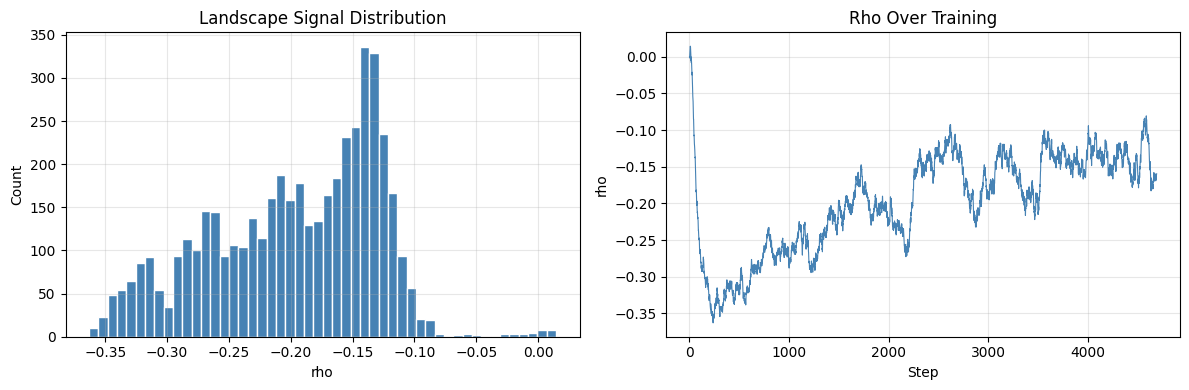

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(halo_diagnostics["rho"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("Count")
axes[0].set_title("Landscape Signal Distribution")
axes[0].grid(True, alpha=0.3)

axes[1].plot(halo_diagnostics["step"], halo_diagnostics["rho"], "-", linewidth=0.8, color="steelblue")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("rho")
axes[1].set_title("Rho Over Training")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Loss Landscape with Optimizer Trajectories

Evaluating loss landscape...


Landscape: 100%|██████████| 625/625 [00:06<00:00, 92.88it/s]


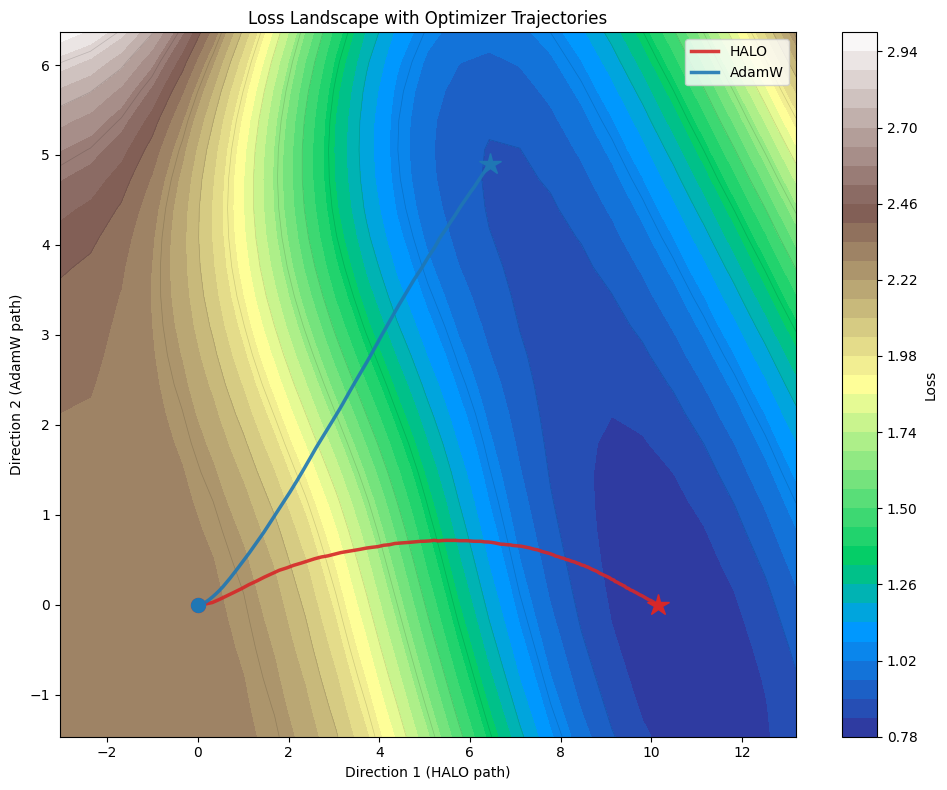

In [19]:
NUM_TRAJ_STEPS = 150
GRID_RES = 25
N_EVAL_BATCHES = 3

criterion_landscape = nn.CrossEntropyLoss()

eval_loader_landscape = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
eval_batches = []
for batch in eval_loader_landscape:
    eval_batches.append(batch)
    if len(eval_batches) >= N_EVAL_BATCHES:
        break
eval_imgs = torch.cat([b[0] for b in eval_batches]).to(DEVICE)
eval_lbls = torch.cat([b[1] for b in eval_batches]).to(DEVICE)
del eval_loader_landscape, eval_batches


def _flat_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])


def _set_flat_params(model, vec):
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(vec[offset:offset + n].view_as(p))
        offset += n


@torch.no_grad()
def _eval_loss_at(model, vec):
    _set_flat_params(model, vec)
    model.eval()
    return criterion_landscape(model(eval_imgs), eval_lbls).item()


def _collect_trajectory(opt_name, num_steps):
    torch.manual_seed(SEED)
    mdl = SmallCNN().to(DEVICE)
    if opt_name == "halo":
        opt = HALO(
            mdl.parameters(), lr=LR, betas=(BETA1, BETA2), eps=EPS,
            weight_decay=WEIGHT_DECAY, gamma=GAMMA,
            eta_phi=ETA_PHI, degree=DEGREE, diagnostics=False,
        )
    else:
        opt = optim.AdamW(
            mdl.parameters(), lr=LR, betas=(BETA1, BETA2), eps=EPS,
            weight_decay=WEIGHT_DECAY,
        )

    g = torch.Generator().manual_seed(SEED)
    loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, generator=g,
    )

    traj = [_flat_params(mdl).cpu()]
    step = 0
    mdl.train()
    while step < num_steps:
        for imgs, lbls in loader:
            if step >= num_steps:
                break
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            opt.zero_grad()
            out = mdl(imgs)
            loss = criterion_landscape(out, lbls)
            loss.backward()
            opt.step()
            traj.append(_flat_params(mdl).cpu())
            step += 1
    return torch.stack(traj)


print("Collecting HALO trajectory...")
h_traj = _collect_trajectory("halo", NUM_TRAJ_STEPS)
print("Collecting AdamW trajectory...")
a_traj = _collect_trajectory("adamw", NUM_TRAJ_STEPS)

origin = h_traj[0]
d1 = (h_traj[-1] - origin).float()
d1 /= d1.norm()
d2 = (a_traj[-1] - origin).float()
d2 -= (d2 @ d1) * d1
if d2.norm() < 1e-8:
    d2 = torch.randn_like(d1)
    d2 -= (d2 @ d1) * d1
d2 /= d2.norm()


def _project(traj):
    delta = (traj - origin).float()
    return torch.stack([delta @ d1, delta @ d2], dim=1).numpy()


h_2d = _project(h_traj)
a_2d = _project(a_traj)

all_pts = np.vstack([h_2d, a_2d])
pad = 0.3
xlo, xhi = all_pts[:, 0].min(), all_pts[:, 0].max()
ylo, yhi = all_pts[:, 1].min(), all_pts[:, 1].max()
xr, yr = xhi - xlo, yhi - ylo
xlo -= pad * xr
xhi += pad * xr
ylo -= pad * yr
yhi += pad * yr

xs = np.linspace(xlo, xhi, GRID_RES)
ys = np.linspace(ylo, yhi, GRID_RES)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)

probe = SmallCNN().to(DEVICE)
total = GRID_RES * GRID_RES
print("Evaluating loss landscape...")
for idx in tqdm(range(total), desc="Landscape"):
    i, j = divmod(idx, GRID_RES)
    vec = (origin + X[i, j] * d1 + Y[i, j] * d2).to(DEVICE)
    Z[i, j] = _eval_loss_at(probe, vec)

fig, ax = plt.subplots(figsize=(10, 8))

cf = ax.contourf(X, Y, Z, levels=40, cmap="terrain")
plt.colorbar(cf, ax=ax, label="Loss")
ax.contour(X, Y, Z, levels=15, colors="k", alpha=0.15, linewidths=0.5)

ax.plot(h_2d[:, 0], h_2d[:, 1], color="#d62728", linewidth=2.5, alpha=0.9, label="HALO")
ax.plot(h_2d[0, 0], h_2d[0, 1], "o", color="#d62728", markersize=10, zorder=5)
ax.plot(h_2d[-1, 0], h_2d[-1, 1], "*", color="#d62728", markersize=16, zorder=5)

ax.plot(a_2d[:, 0], a_2d[:, 1], color="#1f77b4", linewidth=2.5, alpha=0.9, label="AdamW")
ax.plot(a_2d[0, 0], a_2d[0, 1], "o", color="#1f77b4", markersize=10, zorder=5)
ax.plot(a_2d[-1, 0], a_2d[-1, 1], "*", color="#1f77b4", markersize=16, zorder=5)

ax.set_xlabel("Direction 1 (HALO path)")
ax.set_ylabel("Direction 2 (AdamW path)")
ax.set_title("Loss Landscape with Optimizer Trajectories")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Summary

In [16]:
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'HALO':>12} {'AdamW':>12} {'Delta':>12}")
print("-" * 60)

metrics = [
    ("Train Loss", halo_history["train_loss"][-1], adamw_history["train_loss"][-1]),
    ("Val Loss", halo_history["val_loss"][-1], adamw_history["val_loss"][-1]),
    ("Train F1", halo_history["train_f1"][-1], adamw_history["train_f1"][-1]),
    ("Val F1", halo_history["val_f1"][-1], adamw_history["val_f1"][-1]),
]

for name, halo_val, adamw_val in metrics:
    delta = halo_val - adamw_val
    print(f"{name:<20} {halo_val:>12.4f} {adamw_val:>12.4f} {delta:>+12.4f}")

print()
print(f"Final HALO policy (phi, degree={DEGREE}):")
n_per_policy = DEGREE + 1
policy_labels = ["momentum", "normalization", "sign"]
for p_idx, p_name in enumerate(policy_labels):
    coeffs = [halo_diagnostics[f"phi_{p_idx * n_per_policy + k}"][-1] for k in range(n_per_policy)]
    terms = []
    for k, c in enumerate(coeffs):
        power = DEGREE - k
        if power > 0:
            terms.append(f"rho^{power}: {c:.4f}")
        else:
            terms.append(f"bias: {c:.4f}")
    print(f"  {p_name}: {', '.join(terms)}")

FINAL COMPARISON
Metric                       HALO        AdamW        Delta
------------------------------------------------------------
Train Loss                 0.2780       0.3074      -0.0294
Val Loss                   0.3068       0.3513      -0.0445
Train F1                   0.8997       0.8879      +0.0118
Val F1                     0.8926       0.8708      +0.0219

Final HALO policy (phi):
  a1 = -0.0907
  b1 = 1.7935
  a2 = 0.0674
  b2 = 2.6891
  a3 = 0.1349
  b3 = -2.5944
